## 🧬 LLM × Evolutionary Algorithms

### Learning objectives
- Call an LLM (Gemini) from Python and parse the code it returns.
- Use an LLM to generate metaheuristics and benchmark them on a standard test function.
- Iterate on those algorithms with simple evolutionary operators.

### 1. Environment setup
- Sign in to [Google AI Studio](https://aistudio.google.com/api-keys) and generate an API key.
- We use Gemini for its generous free tier (~1500 requests/day).

In [ ]:
# ! pip install google-genai

In [ ]:
from google import genai

MODEL = "gemini-2.5-flash"
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# Smoke test
print(client.models.generate_content(model=MODEL, contents=["Hello, world!"]).text)

Hello, world! It's great to be here with you. How can I help you today?


### 2. Generating metaheuristics with an LLM

LLMs can write Python, so we can ask them to write *optimization algorithms*. The workflow is simple: prompt the model with a function signature, parse the code from its response, and run it on a benchmark.

We'll need a small utility to extract a function from a Markdown code block, validate it, and load it into the current namespace:

In [4]:
import ast
import re
from typing import Any, Callable


class FunctionParser:
    """Extracts a Python function from an LLM response and loads it as a callable.

    LLMs typically return code wrapped in a Markdown ```python ... ``` block,
    often surrounded by explanatory prose. This helper isolates the code,
    checks it parses as valid Python, executes it in a fresh namespace, and
    returns the named function so it can be called like any other callable.
    """

    @staticmethod
    def parse(model_response: str, function_name: str) -> Callable | None:
        """Parse `model_response` and return the function named `function_name`.

        Returns None if no code block is found or if the code is syntactically
        invalid. Otherwise the extracted code is executed and the requested
        function is looked up in the resulting namespace.
        """
        function_str = FunctionParser.extract_code(model_response)
        if not function_str or not FunctionParser.validate_function_syntax(function_str):
            return None
        namespace: dict[str, Any] = {}
        # WARNING: exec runs arbitrary model output. In production this MUST
        # happen inside a sandbox (subprocess, container, restricted runtime).
        exec(function_str, namespace)
        if function_name in namespace:
            return namespace[function_name]
        candidate_names = FunctionParser.list_function_names(function_str)
        if len(candidate_names) == 1 and candidate_names[0] in namespace:
            return namespace[candidate_names[0]]
        raise KeyError(f"Function '{function_name}' not found. Available: {candidate_names}")

    @staticmethod
    def list_function_names(function_str: str) -> list[str]:
        """Return top-level function names from code string."""
        tree = ast.parse(function_str)
        return [node.name for node in tree.body if isinstance(node, ast.FunctionDef)]

    @staticmethod
    def validate_function_syntax(function_str: str) -> bool:
        """Return True iff `function_str` parses as valid Python (AST check only).

        This catches malformed code before we exec it, but does not guarantee
        the code is safe or semantically correct.
        """
        try:
            ast.parse(function_str)
            return True
        except SyntaxError:
            return False

    @staticmethod
    def extract_code(text: str) -> str | None:
        """Pull the first fenced code block or def block out of an LLM response.

        Returns the inner code as a string, or None if no suitable block
        is present.
        """
        fenced_match = re.search(r"```(?:python)?\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
        if fenced_match:
            return fenced_match.group(1)
        def_match = re.search(r"(def\s+\w+\s*\(.*)", text, re.DOTALL)
        return def_match.group(1) if def_match else None

Now ask the LLM to invent a metaheuristic. We pin the function signature so the response is directly executable:

In [6]:
PROMPT_METAHEURISTIC = """
Problem: You are tasked with inventing a novel metaheuristic algorithm capable of minimizing an arbitrary real-valued, 
black-box, single-objective function defined over simple bound constraints.

Write a Python function that implements your algorithm. The function must take exactly these arguments:
- function: Callable[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.

The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.

Your solution should be wrapped in a Markdown Python code block.

```python
import numpy as np 
from typing import Callable
def new_metaheuristic(
	function: Callable[[np.ndarray], float], 
    bounds: list[tuple[float, float]], 
    budget: int
) -> tuple[float, np.ndarray]:
```
"""


response = client.models.generate_content(model=MODEL, contents=[PROMPT_METAHEURISTIC])
print(response.text)

```python
import numpy as np 
from typing import Callable

def new_metaheuristic(
    function: Callable[[np.ndarray], float], 
    bounds: list[tuple[float, float]], 
    budget: int
) -> tuple[float, np.ndarray]:
    """
    Gravitational Swarm Optimization with Adaptive Dynamics and Bounded Reflection (GSO-ADBR)

    This algorithm is a novel metaheuristic inspired by concepts from the Gravitational Search 
    Algorithm (GSA) and Particle Swarm Optimization (PSO). It simulates a swarm of "particles" 
    (candidate solutions) in the search space. Each particle possesses a "mass" that is 
    inversely proportional to its fitness (i.e., better solutions have higher mass). 
    Particles are attracted to each other, with the force of attraction proportional to the 
    masses and inversely proportional to their distance.

    Key features of GSO-ADBR include:
    1.  **Mass-based Attraction:** Particles are drawn towards fitter (more massive) solutions.
    2.  **Adaptive Dynamics:**

# Komentarz
Model LLM wygenerował własny algorytm metaheurystyczny nazwany **GSO-ADBR**. Algorytm działa podobnie do roju cząstek: tworzy grupę losowych rozwiązań, ocenia je funkcją celu i przesuwa cząstki w stronę lepszych rozwiązań. Lepsze cząstki silniej przyciągają pozostałe. Algorytm odpowiednio zmniejsza siłę ruchu, aby najpierw szerzej przeszukiwać przestrzeń, a później poprawiać znalezione rozwiązania.

Parse it and benchmark on Rastrigin (10D, average over 10 seeds):

In [7]:
import random
from typing import Callable

import numpy as np


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))


class OptimizerVerifier:
    def __init__(
        self,
        budget: int = 10_000,
        dims: int = 10,
        seeds_count: int = 10,
        test_function: Callable = rastrigin,
    ) -> None:
        self.budget = budget
        self.dims = dims
        self.seeds_count = seeds_count
        self.test_function = test_function

    def verify(self, optimizer: Callable) -> float:
        bounds = [(-5, 5) for _ in range(self.dims)]
        results = []
        for seed in range(self.seeds_count):
            np.random.seed(seed)
            random.seed(seed)
            best_val, _ = optimizer(self.test_function, bounds, self.budget)
            results.append(best_val)
        return float(np.mean(results))


metaheuristic = FunctionParser.parse(response.text, "new_metaheuristic")
mean_score_for_rastrigin = OptimizerVerifier().verify(metaheuristic)
mean_score_for_rastrigin

38.4147515512273

### 3. Evolution of Heuristics

Each generated metaheuristic has a measurable fitness (its score on the benchmark). That means we can apply crossover and mutation operators to *textual* solutions and run an evolutionary loop in the space of Python functions that represent optimization algorithms.

### Exercise 1
Describe the meta‑heuristic generated by Gemini. Does the idea make sense? Is it novel? What are its weaknesses?

# Komentarz
Wygenerowana przez Gemini metaheurystyka to algorytm rojowy inspirowany PSO i algorytmem grawitacyjnym. Algorytm tworzy populację cząstek, które poruszają się po przestrzeni rozwiązań. Lepsze rozwiązania mają większą 'masę' i przyciągają inne cząstki.

Pomysł łączy znane mechanizmy: populację, przyciąganie do lepszych punktów, losowe zaburzenia i ograniczenie do zadanych granic. Przypomina jednak mocno istniejące algorytmy roju cząstek i gravitational search.

Wynik na Rastriginie 10D wyniósł około 38.41, więc algorytm działa, ale nie znajduje bardzo dobrego minimum. Jego słabością jest dużo ręcznie dobranych parametrów oraz ryzyko utknięcia w lokalnych minimach. Może też być wolniejszy, bo w każdej iteracji liczy wpływ wielu cząstek na siebie.

### Exercise 2
Generate N = 5 distinct algorithms, benchmark them, and report the best.

> **💡 Tip.** The underlying idea is simple: instead of trying to produce a single perfect algorithm, use the LLM as a generator that samples many different approaches. In practice, we could generate thousands of candidate algorithms and automatically evaluate them. Most of them will likely be poor, but that is acceptable — we only need a few strong candidates to discover an effective baseline. The key insight is that the LLM is valuable not just as a solver, but as a high-throughput source of diverse algorithmic ideas.

![monkeys](./monkeys.jpg)

In [8]:
N = 5

algorithm_prompts = [
    "Generate a population-based optimizer inspired by swarm intelligence, but not standard PSO.",
    "Generate an optimizer inspired by local search with random restarts.",
    "Generate an optimizer inspired by differential mutation and recombination.",
    "Generate an optimizer inspired by simulated annealing and adaptive noise.",
    "Generate an optimizer inspired by elite selection and mutation."
]

generated_algorithms = []
scores = []

verifier = OptimizerVerifier(
    budget=10_000,
    dims=10,
    seeds_count=10,
    test_function=rastrigin
)

for i in range(N):
    prompt = PROMPT_METAHEURISTIC + f"""

Important:
This is algorithm number {i + 1}.
Make it clearly different from the others.
Idea direction: {algorithm_prompts[i]}
Return only one complete Python function.
"""

    print(f"\nGenerating algorithm {i + 1}...")

    response_i = client.models.generate_content(
        model=MODEL,
        contents=[prompt]
    )

    try:
        optimizer_i = FunctionParser.parse(response_i.text, "new_metaheuristic")

        if optimizer_i is None:
            print(f"Algorithm {i + 1}: parsing failed")
            scores.append(np.inf)
            generated_algorithms.append(None)
            continue

        score_i = verifier.verify(optimizer_i)

        generated_algorithms.append({
            "response": response_i.text,
            "optimizer": optimizer_i,
            "score": score_i
        })

        scores.append(score_i)

        print(f"Algorithm {i + 1}: mean score = {score_i:.4f}")

    except Exception as e:
        print(f"Algorithm {i + 1}: failed with error: {e}")
        scores.append(np.inf)
        generated_algorithms.append(None)


Generating algorithm 1...
Algorithm 1: mean score = 31.0664

Generating algorithm 2...
Algorithm 2: mean score = 0.1990

Generating algorithm 3...
Algorithm 3: mean score = 45.6542

Generating algorithm 4...
Algorithm 4: mean score = 75.2873

Generating algorithm 5...
Algorithm 5: mean score = 13.6099


In [9]:
best_idx = int(np.argmin(scores))
best_score = scores[best_idx]
best_algorithm = generated_algorithms[best_idx]

print("\nResults:")
for i, score in enumerate(scores):
    print(f"Algorithm {i + 1}: mean score = {score:.4f}")

print("\nBest algorithm:")
print(f"Algorithm {best_idx + 1}")
print(f"Best mean score: {best_score:.4f}")


Results:
Algorithm 1: mean score = 31.0664
Algorithm 2: mean score = 0.1990
Algorithm 3: mean score = 45.6542
Algorithm 4: mean score = 75.2873
Algorithm 5: mean score = 13.6099

Best algorithm:
Algorithm 2
Best mean score: 0.1990


In [10]:
print(best_algorithm["response"])

```python
import numpy as np
from typing import Callable

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]],
    budget: int
) -> tuple[float, np.ndarray]:
    """
    Adaptive Neighborhood Search with Guided Restarts (ANS-GR)

    This metaheuristic combines local search (exploitation) with random restarts (exploration).
    The local search adaptively adjusts its step size: expanding when improvements are found
    and contracting when stagnation occurs. When a local search converges or stagnates
    beyond a threshold, a new search is restarted from a random point in the search space.
    The algorithm always keeps track of the global best solution found across all restarts.

    Args:
        function (Callable[[np.ndarray], float]): The objective function to minimise.
                                                   Takes a NumPy array (decision vector)
                                                   and returns a float 

# Komentarz
Gemini zostało użyte jako generator różnych algorytmów metaheurystycznych. Wygenerowano 5 różnych funkcji optymalizacyjnych, a następnie każdą z nich przetestowano na funkcji Rastrigina w 10 wymiarach. Wynik liczono jako średnią z 10 uruchomień z różnymi ziarnami losowości. Najlepszy algorytm to ten, który uzyskał najniższą średnią wartość funkcji celu.

Najlepszy okazał się algorytm 2, który uzyskał średni wynik 0.199, czyli bardzo blisko minimum globalnego. Działa on jako lokalne przeszukiwanie z restartami, więc poprawia rozwiązania z możliwością zaczynania od nowych punktów. 

Algorytm 5 wypadł całkiem dobrze (13.61), ale był wyraźnie słabszy od algorytmu 2. Algorytmy 1 i 3 osiągnęły średnie wyniki około 31–46, więc znalazły niezbyt dokładne rozwiązania. Najgorzej wypadł algorytm 4 z wynikiem 75.29, co oznacza, że prawdopodobnie miał problem z wyjścia z lokalnych minimów.

Wniosek jest taki, że generowanie wielu algorytmów ma sens, bo wśród kilku prób może pojawić się bardzo dobry kandydat.

### Exercise 3
Review [Evolution of Heuristics: Towards Efficient Automatic Algorithm Design Using Large Language Model](https://arxiv.org/pdf/2401.02051) and read **3.4 Prompt Strategies**. Re-implement one of the prompt strategies (M1, M2, or M3). For reference, here's the [GitHub repository](https://github.com/FeiLiu36/EoH) and here's the key [file](https://github.com/FeiLiu36/EoH/blob/main/eoh/src/eoh/methods/eoh/eoh_evolution.py) with all prompts.

<details><summary><b>Hint 1</b></summary><br>Read <code>get_prompt_m2</code> method and adapt it to our case (signature of the function is slightly different, but the idea is the same).</details>


<details><summary><b>Hint 2</b></summary><br>The core idea behind M2 is: "Please identify the main algorithm parameters and assist me in creating a new algorithm with different parameter settings for the provided score function." We should incorporate this instruction directly into the prompt together with the generated metaheuristic.</details>


<details><summary><b>Comment</b></summary><br>In the paper they describe it as "M2: Modify the parameters of one selected heuristic. First, one heuristic is selected from the current population. Then, LLM is prompted to try different parameters in the current heuristic instead of designing a new one." In practice, though, the idea is extremely simple.</details>


<details><summary><b>Hint 3</b></summary><br>Use a prompt like this:<pre>I have one algorithm with its code as follows.
```python
{metaheuristic}
```
Please identify the main algorithm parameters and assist me in creating a new algorithm that has a different parameter settings.
Write a Python function that implements your algorithm. The function must take exactly these arguments:
- function: Callable[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.
The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.
Your solution should be wrapped in a Markdown Python code block.
```python
import numpy as np
def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]],
    budget: int
) -> tuple[float, np.ndarray]:
    ...
```
Do not give additional explanations.</pre></details>

In [11]:
def make_m2_prompt(metaheuristic_response: str) -> str:
    metaheuristic_code = FunctionParser.extract_code(metaheuristic_response)

    prompt = f'''
I have one algorithm with its code as follows.

```python
{metaheuristic_code}
```

Please identify the main algorithm parameters and assist me in creating a new algorithm that has different parameter settings.
Do not design a completely new algorithm. Keep the same general idea, but modify the important parameters.

Write a Python function that implements your algorithm. The function must take exactly these arguments:
- function: Callable[[np.ndarray], float] - the objective function to minimise.
- bounds: list[tuple[float, float]] - a list of (lower, upper) pairs delimiting the search space for each dimension.
- budget: int - the total number of objective-function evaluations the algorithm may perform.

The function should return a tuple[float, np.ndarray] containing the best objective value found and the corresponding decision vector.

Your solution should be wrapped in a Markdown Python code block.

```python
import numpy as np
from typing import Callable

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]],
    budget: int
) -> tuple[float, np.ndarray]:
    ...
```

Do not give additional explanations.
'''
    return prompt

In [12]:
m2_prompt = make_m2_prompt(best_algorithm["response"])

m2_response = client.models.generate_content(
    model=MODEL,
    contents=[m2_prompt]
)

print(m2_response.text)

```python
import numpy as np
from typing import Callable

def new_metaheuristic(
    function: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]],
    budget: int
) -> tuple[float, np.ndarray]:
    """
    Adaptive Neighborhood Search with Guided Restarts (ANS-GR) - Variant B

    This variant explores with different parameter settings compared to the original.
    It aims for a more aggressive step size adaptation and allows local searches
    to persist longer before a restart.

    Args:
        function (Callable[[np.ndarray], float]): The objective function to minimise.
                                                   Takes a NumPy array (decision vector)
                                                   and returns a float (objective value).
        bounds (list[tuple[float, float]]): A list of (lower, upper) pairs delimiting
                                            the search space for each dimension.
        budget (int): The total number of objective-fu

In [13]:
m2_metaheuristic = FunctionParser.parse(
    m2_response.text,
    "new_metaheuristic"
)

m2_score = OptimizerVerifier(
    budget=10_000,
    dims=10,
    seeds_count=10,
    test_function=rastrigin
).verify(m2_metaheuristic)

print(f"Original best score: {best_score:.4f}")
print(f"M2 modified score: {m2_score:.4f}")

Original best score: 0.1990
M2 modified score: 0.2985


# Komentarz
Strategia M2 wygenerowała zmodyfikowaną wersję najlepszego algorytmu, zmieniając jego parametry zamiast tworzyć nową metodę od zera. Wynik pogorszył się z 0.1990 do 0.2985, więc w tym przypadku zmiana parametrów nie była korzystna. 
Mimo to algorytm nadal działał dobrze, ponieważ wynik pozostał blisko minimum globalnego. Pokazuje to, że automatyczne modyfikowanie parametrów może być przydatne, ale nie każda mutacja poprawia jakość rozwiązania.

Is the mutated algorithm better than the original one? How different is it from the original? Experiment with modifying the prompt and observe how the generated algorithm changes. Can you obtain a significant improvement over the original metaheuristic?

# Komentarz
Mutowany algorytm nie był lepszy od oryginalnego. Wynik lekko się pogorszył. Różnica nie jest duża, bo oba wyniki są blisko zera, ale poprawy nie udało się uzyskać.

Algorytm po mutacji nie zmienił całej idei działania. Nadal jest to lokalne przeszukiwanie z restartami, tylko z innymi parametrami. Zmieniono m.in. większy początkowy krok, mocniejszą zmianę kroku oraz dłuższe czekanie przed restartem.

Eksperyment pokazuje, że sama zmiana promptu i parametrów może wpływać na wynik, ale nie gwarantuje poprawy. W tym przypadku nie uzyskano znaczącej poprawy względem oryginalnej. Oryginalny algorytm był już bardzo dobry, więc dalsze ulepszenie było trudne.

### Exercise 3:
Implement Evolution of Heuristics (or at least part of it). Start simple (pseudocode):
```
current_population = [generate_heuristic()]
for _ in range(10):
   parent = current_population[-1]
   new_solution = M2(parent)
   f_new_solution = verify(new_solution)
   current_population.append(new_solution)
```
Save all generated solutions, preferably using a separate file for each one. Analyse the generated algorithms and identify the most common ideas or design patterns. Plot the solution quality across epochs and investigate whether the iterative process exhibits convergence.

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def run_m2(parent_response: str):
    prompt = make_m2_prompt(parent_response)

    response = client.models.generate_content(
        model=MODEL,
        contents=[prompt]
    )

    optimizer = FunctionParser.parse(response.text, "new_metaheuristic")

    score = OptimizerVerifier(
        budget=10_000,
        dims=10,
        seeds_count=10,
        test_function=rastrigin
    ).verify(optimizer)

    return response.text, optimizer, score

In [20]:
output_dir = Path("generated_heuristics")
output_dir.mkdir(exist_ok=True)

epochs = 10

population = []

# Startujemy od najlepszego algorytmu z Exercise 2
initial_response = best_algorithm["response"]
initial_score = best_score

population.append({
    "epoch": 0,
    "response": initial_response,
    "score": initial_score
})

# zapis algorytmu startowego
(output_dir / "heuristic_epoch_0.py").write_text(
    FunctionParser.extract_code(initial_response),
    encoding="utf-8"
)

print(f"Epoch 0: score = {initial_score:.4f}")

for epoch in range(1, epochs + 1):
    parent_response = population[-1]["response"]

    try:
        new_response, new_optimizer, new_score = run_m2(parent_response)

        population.append({
            "epoch": epoch,
            "response": new_response,
            "score": new_score
        })

        code = FunctionParser.extract_code(new_response)
        (output_dir / f"heuristic_epoch_{epoch}.py").write_text(
            code,
            encoding="utf-8"
        )

        print(f"Epoch {epoch}: score = {new_score:.4f}")

    except Exception as e:
        print(f"Epoch {epoch}: failed, error = {e}")
        break

Epoch 0: score = 0.1990
Epoch 1: score = 0.2490
Epoch 2: score = 0.7960
Epoch 3: score = 0.0000
Epoch 4: score = 0.7960
Epoch 5: score = 0.3166
Epoch 6: score = 0.7960
Epoch 7: score = 0.0359
Epoch 8: score = 0.0000
Epoch 9: failed, error = 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 48.728874116s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations

In [21]:
eoh_df = pd.DataFrame([
    {
        "epoch": item["epoch"],
        "score": item["score"]
    }
    for item in population
])

eoh_df

,epoch,score
0,0,1.989918e-01
1,1,2.489697e-01
2,2,7.959672e-01
3,3,1.811879e-07
4,4,7.959672e-01
5,5,3.165922e-01
6,6,7.959672e-01
7,7,3.588560e-02
8,8,3.658004e-06


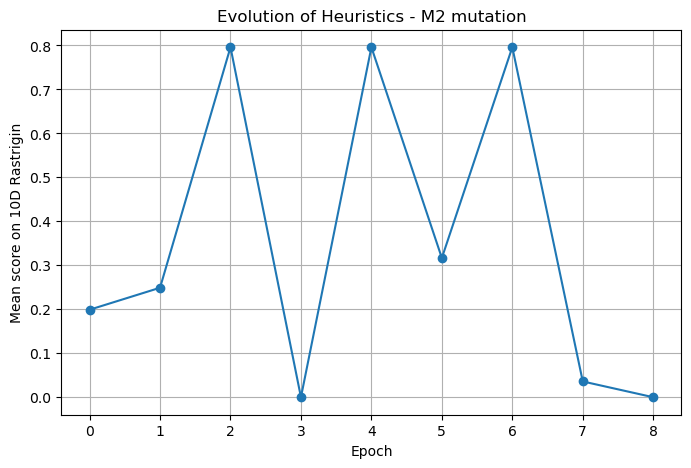

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(eoh_df["epoch"], eoh_df["score"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Mean score on 10D Rastrigin")
plt.title("Evolution of Heuristics - M2 mutation")
plt.grid(True)
plt.show()

In [23]:
patterns = {
    "random restart": ["restart"],
    "local search": ["local search", "neighbor", "neighborhood"],
    "adaptive step size": ["step_size", "adaptive", "contraction", "expansion"],
    "population": ["population", "swarm", "particles"],
    "mutation": ["mutation", "mutant"],
    "elite/best solution": ["best", "elite"],
    "annealing/noise": ["annealing", "temperature", "noise"]
}

pattern_counts = {name: 0 for name in patterns}

for item in population:
    text = item["response"].lower()

    for pattern_name, keywords in patterns.items():
        if any(keyword in text for keyword in keywords):
            pattern_counts[pattern_name] += 1

pattern_df = pd.DataFrame(
    pattern_counts.items(),
    columns=["pattern", "count"]
).sort_values("count", ascending=False)

pattern_df

,pattern,count
0,random restart,9
1,local search,9
2,adaptive step size,9
5,elite/best solution,9
3,population,0
4,mutation,0
6,annealing/noise,0


# Komentarz
W eksperymencie wykonano prostą wersję Evolution of Heuristics ze strategią M2. Startowym rozwiązaniem był najlepszy algorytm z poprzedniego zadania, a w kolejnych epokach Gemini modyfikowało jego parametry. Wyniki nie poprawiały się regularnie. Część mutacji pogarszała jakość algorytmu, np. w epokach 2, 4 i 6 wynik wynosił około 0.7960.

Najlepsze wyniki pojawiły się w epokach 3 i 8, gdzie wartość funkcji była prawie równa 0. Oznacza to, że proces potrafił znaleźć bardzo dobrą wersję algorytmu, ale nie działał stabilnie w każdej iteracji. Widać więc, że mutowanie heurystyk może prowadzić do poprawy, ale każda kolejna zmiana nie musi być lepsza od poprzedniej.

Analiza wzorców pokazała, że najczęściej pojawiały się: losowe restarty, lokalne przeszukiwanie, adaptacyjny rozmiar kroku oraz zapamiętywanie najlepszego rozwiązania. Oznacza to, że Gemini głównie modyfikowało ten sam typ algorytmu, zamiast tworzyć zupełnie nowe podejścia co jest zgodne z strategią M2.

### 4. Recommended Reading
- [AlphaEvolve: A Gemini-powered coding agent for designing advanced algorithms](https://deepmind.google/discover/blog/alphaevolve-a-gemini-powered-coding-agent-for-designing-advanced-algorithms/)
- Shojaee, Parshin, et al. [LLM-SR: Scientific equation discovery via programming with large language models.](https://arxiv.org/abs/2404.18400)
- Romera-Paredes, Bernardino, et al. [Mathematical discoveries from program search with large language models.](https://www.nature.com/articles/s41586-023-06924-6)
- van Stein, Niki, and Thomas Bäck. [Llamea: A large language model evolutionary algorithm for automatically generating metaheuristics.](https://arxiv.org/abs/2405.20132)
- Liu, Fei, et al. [Evolution of heuristics: Towards efficient automatic algorithm design using large language model.](https://arxiv.org/abs/2401.02051)
- van Stein, Niki, et al. [BLADE: Benchmark suite for LLM-driven Automated Design and Evolution of iterative optimisation heuristics](https://arxiv.org/html/2504.20183v1)
- [OpenEvolve](https://github.com/codelion/openevolve)